In [1]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [2]:
df = pd.DataFrame()

df["X1"] = [1, 2, 3, 4, 5, 6, 6, 7, 9, 9]
df["X2"] = [5, 3, 6, 8, 1, 9, 5, 8, 9, 2]
df["label"] = [1, 1, 0, 1, 0, 1, 0, 1, 0, 0]

df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

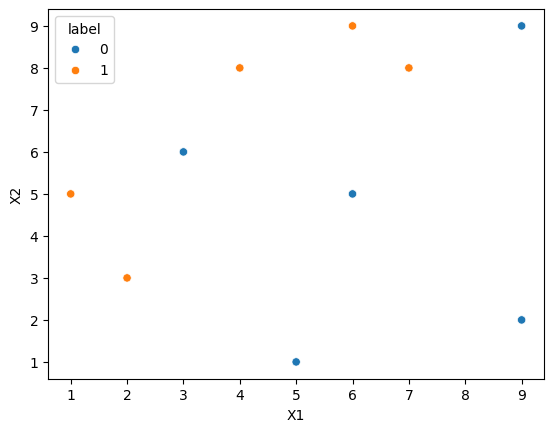

In [ ]:
import seaborn as sns

sns.scatterplot(x=df["X1"], y=df["X2"], hue=df["label"])

---
## Adaboost Algorithm

##### Step 1: Assign weights to each row

In [ ]:
df["weights"] = 1 / df.shape[0]
df.head()

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1


#### Step 2: Use decision `stumps`

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt1 = DecisionTreeClassifier(max_depth=1)

X = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

dt1.fit(X, y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

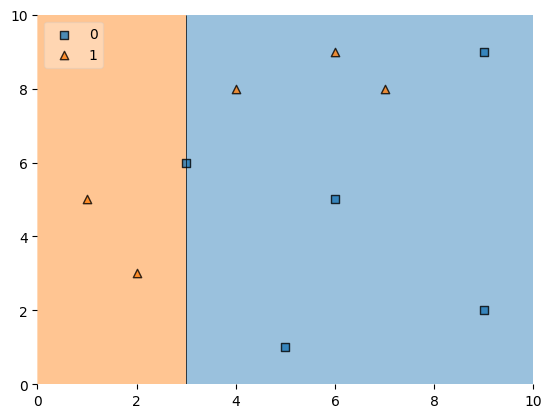

In [9]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [12]:
df["y_pred"] = dt1.predict(X)
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


#### Step 3: Calculate model weight

In [ ]:
def calculate_model_weight(error: float) -> float:
    return 0.5 * np.log((1 - error) / (error + 0.000000001))

In [13]:
alpha1 = calculate_model_weight(0.3)
alpha1

0.42364893019360184

#### Step 4: Update Weights

In [ ]:
def update_row_weights(row, alpha=0.423) -> None:
    if row["label"] == row["y_pred"]:
        return row["weights"] * np.exp(-alpha)
    else:
        return row["weights"] * np.exp(alpha)


In [15]:
df["updated_weights"] = df.apply(update_row_weights, axis=1)
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
7,7,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [ ]:
sum = df["updated_weights"].sum()
df["normalized_weights"] = df["updated_weights"] / sum
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,6,5,0,0.1,0,0.065508,0.071475
7,7,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475
